# DNN → CNN 실습: MNIST 손글씨 숫자 분류

손글씨 숫자 이미지 데이터셋인 **MNIST**를 가지고
DNN과 CNN을 직접 만들어보는 실습입니다.


## 전체 구성

각 파트는 두 단계로 진행됩니다.

1. **기초 실습**: 아주 단순한 구조를 직접 만들어보면서 "Dense/Conv 층을 어떻게 쌓는지" 연습해봅니다.
2. **논문 구조 재현**: 딥러닝 역사에서 실제로 쓰였던 유명한 구조를 그대로 만들어봅니다.
   - DNN에서는 Yann LeCun이 1998년 논문에서 MNIST 벤치마크로 사용한 **784→300→100→10 MLP**
   - CNN에서는 손글씨 인식을 위해 설계된 최초의 성공적인 CNN인 **LeNet-5**

## 1. 라이브러리 불러오기

딥러닝 모델을 만들고 학습시키는 데 필요한 도구들을 불러옵니다.
- `tensorflow` / `keras`: 딥러닝 모델을 정의하고 학습시키는 프레임워크
- `matplotlib`: 이미지와 그래프를 그려서 눈으로 확인하기 위한 도구
- `numpy`: 숫자 배열(행렬) 연산


In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


## 2. 데이터 불러오기 및 전처리

**MNIST**는 사람이 손으로 쓴 0~9 숫자 이미지 7만 장으로 이루어진 데이터셋입니다.
각 이미지는 28x28 픽셀 크기의 흑백 이미지이고, 훈련용 60,000장 / 테스트용 10,000장으로 나뉘어 있습니다.
케라스에 내장되어 있어서 별도 다운로드 없이 한 줄로 불러올 수 있습니다.

각 픽셀 값은 0(검정)~255(흰색) 사이의 정수입니다. 신경망은 값의 범위가 작고 일정할 때 학습이 더 안정적이고
빠르게 되는 경향이 있어서, 픽셀 값을 **0~1 사이로 정규화(normalization)** 해줍니다. (255로 나누면 됩니다)

### 🔲 TODO


In [11]:
# TODO 1: tf.keras.datasets.mnist.load_data() 를 이용해서
#          (x_train, y_train), (x_test, y_test) 를 불러오는 코드를 작성하세요.

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()


# TODO 2: x_train, x_test 를 각각 255로 나눠서 0~1 사이 값으로 정규화하세요.

x_train = x_train / 255.0
x_test = x_test / 255.0

print("훈련 데이터 shape:", x_train.shape)
print("테스트 데이터 shape:", x_test.shape)


훈련 데이터 shape: (60000, 28, 28)
테스트 데이터 shape: (10000, 28, 28)


## 3. 데이터 확인해보기

실제로 어떤 이미지들인지 눈으로 확인해봅니다. `imshow`로 이미지를 그리고, 정답 라벨을 제목으로 표시합니다.
이 셀은 그대로 실행하시면 됩니다.


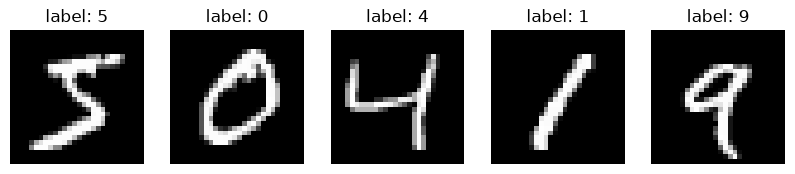

In [12]:
fig, axes = plt.subplots(1, 5, figsize=(10,2))
for i in range(5):
    axes[i].imshow(x_train[i], cmap='gray')
    axes[i].set_title(f"label: {y_train[i]}")
    axes[i].axis('off')
plt.show()


---
# 📘 DNN 파트

DNN(Deep Neural Network)은 여러 개의 **완전연결층(Dense layer)** 을 쌓아 만든 신경망입니다.
완전연결층이란 이전 층의 모든 뉴런이 다음 층의 모든 뉴런과 연결되어 있는 구조를 말합니다.
이미지처럼 2차원으로 생긴 데이터를 Dense layer에 넣으려면, 먼저 1차원으로 펼쳐야(`Flatten`) 합니다.
단, 이 과정에서 "어떤 픽셀이 어떤 픽셀 옆에 있었는지"와 같은 공간 정보는 사라진다는 점을 기억해두세요.
(뒤에서 CNN과 비교할 때 중요한 포인트가 됩니다)

## 4. [기초 실습] 은닉층 1개짜리 DNN 만들기

가장 단순한 형태의 DNN을 만들어봅니다. 층 구성은 다음과 같습니다.
- `Flatten(input_shape=(28,28))`: 28x28 이미지를 784개짜리 1차원 벡터로 펼침
- `Dense(64, relu)`: 은닉층. 64개의 뉴런이 입력으로부터 특징을 조합해서 학습
  - `relu`는 활성화 함수로, 음수는 0으로 만들고 양수는 그대로 통과시켜서 신경망이 비선형적인(복잡한) 패턴을 학습할 수 있게 해줍니다.
- `Dense(10, softmax)`: 출력층. 0~9 중 하나를 고르는 문제이므로 뉴런 10개
  - `softmax`는 10개의 출력을 "각 숫자일 확률"처럼 합이 1이 되게 변환해주는 함수입니다.

모델을 만든 뒤에는 `compile`로 학습 방식을 정하고, `fit`으로 실제 학습을 진행합니다.
- `optimizer='adam'`: 가중치를 얼마나, 어떤 방향으로 업데이트할지 정하는 알고리즘. 대부분의 경우 무난하게 잘 동작해서 기본값으로 많이 씁니다.
- `loss='sparse_categorical_crossentropy'`: 정답과 예측이 얼마나 다른지 측정하는 함수. 정답 라벨이 0~9 같은 정수 형태일 때 사용합니다.
- `metrics=['accuracy']`: 학습 중 정확도를 함께 출력해서 모니터링합니다.
- `epochs=5`: 전체 훈련 데이터를 5번 반복해서 학습합니다.
- `validation_split=0.1`: 훈련 데이터의 10%를 학습에 쓰지 않고 따로 떼어놓아, 매 epoch마다 "본 적 없는 데이터"에서의 성능(과적합 여부)을 확인합니다.

### 🔲 TODO


In [13]:
# TODO: 아래 4개 층을 순서대로 쌓은 Sequential 모델을 만드세요.
#   1) Flatten, input_shape=(28,28)
#   2) Dense, 유닛 64개, activation='relu'
#   3) Dense, 유닛 10개, activation='softmax' (출력층)
dnn_basic = models.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

dnn_basic.summary()

# TODO: optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'] 로 컴파일하세요.

dnn_basic.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

# TODO: x_train, y_train 으로 5 epoch, validation_split=0.1 로 학습시키고
#       결과를 dnn_basic_history 변수에 저장하세요.

dnn_basic_history = dnn_basic.fit(x_train, y_train, epochs=5, validation_split=0.1)

/Users/gomdori/Library/Mobile Documents/com~apple~CloudDocs/BOAZ/BASE/27Analysis_BASE-Week1/.venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 881us/step - accuracy: 0.9086 - loss: 0.3259 - val_accuracy: 0.9628 - val_loss: 0.1474
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 750us/step - accuracy: 0.9553 - loss: 0.1523 - val_accuracy: 0.9680 - val_loss: 0.1137
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 702us/step - accuracy: 0.9680 - loss: 0.1109 - val_accuracy: 0.9698 - val_loss: 0.1000
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 712us/step - accuracy: 0.9741 - loss: 0.0871 - val_accuracy: 0.9692 - val_loss: 0.0999
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 792us/step - accuracy: 0.9787 - loss: 0.0719 - val_accuracy: 0.9738 - val_loss: 0.0911


## 5. [기초 실습] DNN 평가

테스트 데이터(학습에 전혀 쓰이지 않은 데이터)로 최종 성능을 확인합니다.

In [14]:
dnn_basic_loss, dnn_basic_acc = dnn_basic.evaluate(x_test, y_test)
print(f"[기초 실습 DNN] 테스트 정확도: {dnn_basic_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 450us/step - accuracy: 0.9736 - loss: 0.0905
[기초 실습 DNN] 테스트 정확도: 0.9736


## 6. [논문 구조 재현] LeCun의 1998년 MNIST 벤치마크 MLP

Yann LeCun 등이 1998년 논문("Gradient-Based Learning Applied to Document Recognition")에서
MNIST 성능 비교표에 사용했던 구조 중 하나가 **784 → 300 → 100 → 10** 구조의 다층 퍼셉트론(MLP)입니다.
지금 기준으로 보면 아주 단순한 구조지만, 딥러닝 교재/논문에서 비교 기준(baseline)으로 지금도 자주 인용되는
역사적으로 의미 있는 구조입니다.

구조는 기초 실습과 똑같은 패턴이고, 은닉층의 뉴런 개수와 층 개수만 다릅니다.
앞의 코드를 참고해도 좋지만 최대한 본인 힘으로 해보시길 추천드립니다.
- `Dense(300, relu)`
- `Dense(100, relu)`
- `Dense(10, softmax)`

### 🔲 TODO


In [15]:
# TODO: 아래 4개 층을 순서대로 쌓은 Sequential 모델을 만드세요.
#   1) Flatten, input_shape=(28,28)
#   2) Dense, 유닛 300개, activation='relu'
#   3) Dense, 유닛 100개, activation='relu'
#   4) Dense, 유닛 10개, activation='softmax' (출력층)
dnn_paper = models.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(300, activation='relu'),
    layers.Dense(100, activation='relu'),
    layers.Dense(10, activation='softmax')
])


dnn_paper.summary()

# TODO: optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'] 로 컴파일하세요.
dnn_paper.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# TODO: x_train, y_train 으로 5 epoch, validation_split=0.1 로 학습시키고
#       결과를 dnn_paper_history 변수에 저장하세요.

dnn_paper_history = dnn_paper.fit(x_train, y_train, epochs=5, validation_split=0.1)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9366 - loss: 0.2132 - val_accuracy: 0.9735 - val_loss: 0.0937
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9732 - loss: 0.0865 - val_accuracy: 0.9778 - val_loss: 0.0828
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9809 - loss: 0.0620 - val_accuracy: 0.9795 - val_loss: 0.0720
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9857 - loss: 0.0434 - val_accuracy: 0.9798 - val_loss: 0.0752
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9887 - loss: 0.0345 - val_accuracy: 0.9798 - val_loss: 0.0761


## 7. [논문 구조 재현] DNN 평가

In [16]:
dnn_paper_loss, dnn_paper_acc = dnn_paper.evaluate(x_test, y_test)
print(f"[LeCun 1998 MLP] 테스트 정확도: {dnn_paper_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 649us/step - accuracy: 0.9822 - loss: 0.0641
[LeCun 1998 MLP] 테스트 정확도: 0.9822


---
# 📘 CNN 파트

CNN(Convolutional Neural Network)은 이미지를 펼치지 않고, **합성곱(Convolution)** 이라는 연산으로
이미지의 공간 정보(픽셀 간 위치 관계)를 유지한 채 특징을 추출하는 신경망입니다.
작은 필터(커널)가 이미지 위를 슬라이딩하면서 엣지, 곡선 같은 지역적인 패턴을 찾아냅니다.

## 8. CNN을 위한 데이터 준비

`Conv2D` 층은 입력으로 **(높이, 너비, 채널)** 형태의 3차원 데이터를 기대합니다.
지금 데이터는 (28, 28) 형태인데(흑백이라 채널 정보가 따로 없음), 채널 차원 1을 추가해서
(28, 28, 1) 형태로 바꿔줘야 합니다. `reshape(-1, 28, 28, 1)`에서 `-1`은 "이미지 개수는 자동으로 맞춰라"는 뜻입니다.

### 🔲 TODO


In [17]:
# TODO: x_train, x_test를 각각 (개수, 28, 28, 1) 형태로 reshape 하세요.

x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)

print("CNN용 훈련 데이터 shape:", x_train_cnn.shape)
print("CNN용 테스트 데이터 shape:", x_test_cnn.shape)

CNN용 훈련 데이터 shape: (60000, 28, 28, 1)
CNN용 테스트 데이터 shape: (10000, 28, 28, 1)


## 9. [기초 실습] Conv층 1개짜리 CNN 만들기

가장 단순한 형태의 CNN을 만들어봅니다.
- `Conv2D(16, (3,3), relu)`: 3x3 크기의 필터 16개를 이미지 위에 슬라이딩하며 특징(엣지 등)을 추출
- `MaxPooling2D((2,2))`: 2x2 영역에서 가장 큰 값만 남겨서 feature map 크기를 절반으로 줄임 (연산량 감소 + 중요한 특징 강조)
- `Flatten` + `Dense(10, softmax)`: 추출된 특징을 1차원으로 펼쳐서 최종 분류

### 🔲 TODO


In [18]:
# TODO: 아래 4개 층을 순서대로 쌓은 Sequential 모델을 만드세요.
#   1) Conv2D, 필터 16개, 커널 (3,3), activation='relu', input_shape=(28,28,1)
#   2) MaxPooling2D, 풀 크기 (2,2)
#   3) Flatten
#   4) Dense, 유닛 10개, activation='softmax' (출력층)
cnn_basic = models.Sequential([ 
    layers.Conv2D(16, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(10, activation='softmax')
])

cnn_basic.summary()

# TODO: optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'] 로 컴파일하세요.

cnn_basic.compile(optimizer='adam', 
                   loss='sparse_categorical_crossentropy', 
                   metrics=['accuracy'])

# TODO: x_train_cnn, y_train 으로 5 epoch, validation_split=0.1 로 학습시키고
#       결과를 cnn_basic_history 변수에 저장하세요.

cnn_basic_history = cnn_basic.fit(x_train_cnn, y_train, epochs=5, validation_split=0.1)

/Users/gomdori/Library/Mobile Documents/com~apple~CloudDocs/BOAZ/BASE/27Analysis_BASE-Week1/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 2704)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │        27,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,210 (106.29 KB)

 Trainable params: 27,210 (106.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9228 - loss: 0.2729 - val_accuracy: 0.9730 - val_loss: 0.1061
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9710 - loss: 0.1029 - val_accuracy: 0.9788 - val_loss: 0.0772
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9784 - loss: 0.0753 - val_accuracy: 0.9845 - val_loss: 0.0657
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9819 - loss: 0.0617 - val_accuracy: 0.9823 - val_loss: 0.0642
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9842 - loss: 0.0526 - val_accuracy: 0.9823 - val_loss: 0.0641


## 10. [기초 실습] CNN 평가

In [19]:
cnn_basic_loss, cnn_basic_acc = cnn_basic.evaluate(x_test_cnn, y_test)
print(f"[기초 실습 CNN] 테스트 정확도: {cnn_basic_acc:.4f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9809 - loss: 0.0591
[기초 실습 CNN] 테스트 정확도: 0.9809


## 11. [논문 구조 재현] LeNet-5 (Yann LeCun, 1998)

**LeNet-5**는 손글씨 숫자 인식을 위해 설계된 최초의 성공적인 CNN 구조로,
오늘날까지 이어지는 "Conv → Pool → Conv → Pool → Dense" CNN 설계의 기본 틀을 확립한 역사적인 모델입니다.
원 논문은 활성화 함수로 `tanh`, 풀링으로 average pooling을 사용했지만, 여기서는 현대적인 관례에 맞춰
`relu`와 `MaxPooling`으로 구현합니다.

- `Conv2D(6, (5,5), relu)` → `MaxPooling2D((2,2))`
- `Conv2D(16, (5,5), relu)` → `MaxPooling2D((2,2))`
- `Flatten` → `Dense(120, relu)` → `Dense(84, relu)` → `Dense(10, softmax)`

> 참고: 원래 LeNet-5는 32x32 크기 입력을 가정하고 설계됐지만 MNIST는 28x28입니다.
> 그대로 두면 두 번째 풀링을 거친 후 feature map이 너무 작아져서 구조가 어긋나므로,
> 첫 Conv2D에 `padding='same'`을 줘서 크기를 보정합니다.

### 🔲 TODO


In [20]:
# TODO: 아래 8개 층을 순서대로 쌓은 Sequential 모델을 만드세요. (LeNet-5 구조)
#   1) Conv2D, 필터 6개,  커널 (5,5), activation='relu', padding='same', input_shape=(28,28,1)
#   2) MaxPooling2D, 풀 크기 (2,2)
#   3) Conv2D, 필터 16개, 커널 (5,5), activation='relu'
#   4) MaxPooling2D, 풀 크기 (2,2)
#   5) Flatten
#   6) Dense, 유닛 120개, activation='relu'
#   7) Dense, 유닛 84개,  activation='relu'
#   8) Dense, 유닛 10개,  activation='softmax' (출력층)
lenet5 = models.Sequential([
    layers.Conv2D(6, (5,5), activation='relu', padding='same', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(16, (5,5), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(120, activation='relu'),
    layers.Dense(84, activation='relu'),
    layers.Dense(10, activation='softmax')

])


lenet5.summary()

# TODO: optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'] 로 컴파일하세요.

lenet5.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

# TODO: x_train_cnn, y_train 으로 5 epoch, validation_split=0.1 로 학습시키고
#       결과를 lenet5_history 변수에 저장하세요.

lenet5_history = lenet5.fit(x_train_cnn, y_train, epochs=5, validation_split=0.1)

/Users/gomdori/Library/Mobile Documents/com~apple~CloudDocs/BOAZ/BASE/27Analysis_BASE-Week1/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9429 - loss: 0.1904 - val_accuracy: 0.9745 - val_loss: 0.0900
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9798 - loss: 0.0647 - val_accuracy: 0.9840 - val_loss: 0.0573
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9851 - loss: 0.0477 - val_accuracy: 0.9860 - val_loss: 0.0451
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9890 - loss: 0.0361 - val_accuracy: 0.9872 - val_loss: 0.0451
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9913 - loss: 0.0290 - val_accuracy: 0.9888 - val_loss: 0.0447


## 12. [논문 구조 재현] LeNet-5 평가

In [21]:
lenet5_loss, lenet5_acc = lenet5.evaluate(x_test_cnn, y_test)
print(f"[LeNet-5] 테스트 정확도: {lenet5_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9887 - loss: 0.0373
[LeNet-5] 테스트 정확도: 0.9887


---
## 13. 전체 결과 비교

지금까지 만든 4개 모델(기초 실습 DNN / 논문 구조 DNN(LeCun MLP) / 기초 실습 CNN / 논문 구조 CNN(LeNet-5))의
정확도와 파라미터 수를 한눈에 비교해봅니다.


In [23]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'AppleGothic'  
plt.rcParams['axes.unicode_minus'] = False   

모델                        테스트 정확도        파라미터 수         
DNN (기초 실습)               0.9736         50,890         
DNN (논문 구조, LeCun MLP)    0.9822         266,610        
CNN (기초 실습)               0.9809         27,210         
CNN (논문 구조, LeNet-5)      0.9887         61,706         


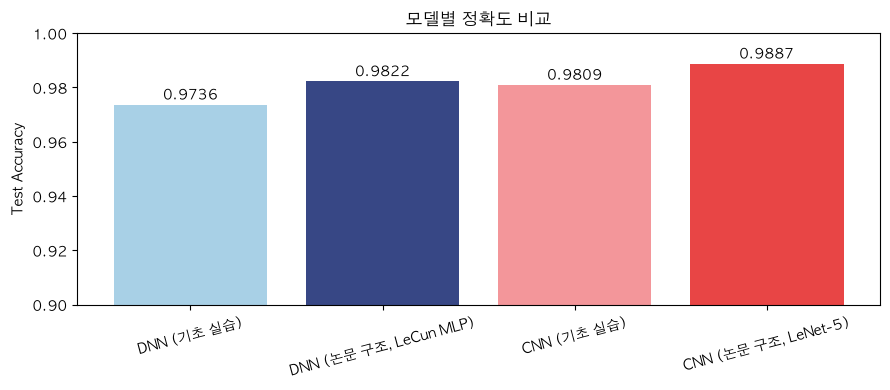

In [24]:
results = {
    "DNN (기초 실습)": (dnn_basic_acc, dnn_basic.count_params()),
    "DNN (논문 구조, LeCun MLP)": (dnn_paper_acc, dnn_paper.count_params()),
    "CNN (기초 실습)": (cnn_basic_acc, cnn_basic.count_params()),
    "CNN (논문 구조, LeNet-5)": (lenet5_acc, lenet5.count_params()),
}

print(f"{'모델':<26}{'테스트 정확도':<15}{'파라미터 수':<15}")
for name, (acc, params) in results.items():
    print(f"{name:<26}{acc:<15.4f}{params:<15,}")

names = list(results.keys())
accs = [v[0] for v in results.values()]

plt.figure(figsize=(9,4))
plt.bar(names, accs, color=['#a8d0e6','#374785','#f3969a','#e84545'])
plt.ylim(0.9, 1.0)
plt.ylabel('Test Accuracy')
plt.title('모델별 정확도 비교')
plt.xticks(rotation=15)
for i, v in enumerate(accs):
    plt.text(i, v+0.002, f"{v:.4f}", ha='center')
plt.tight_layout()
plt.show()

## 14. LeNet-5가 학습한 필터 시각화

CNN의 첫 번째 Conv층이 어떤 패턴을 스스로 학습했는지 눈으로 확인해봅니다.
사람이 정해준 필터가 아니라, 학습 과정에서 데이터로부터 스스로 만들어낸 필터라는 점이 포인트입니다.
이 셀은 그대로 실행하세요.


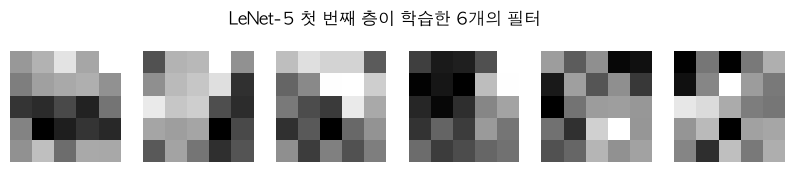

In [25]:
first_conv_weights = lenet5.layers[0].get_weights()[0]  # shape: (5,5,1,6)

fig, axes = plt.subplots(1, 6, figsize=(10,2))
for i, ax in enumerate(axes.flat):
    ax.imshow(first_conv_weights[:,:,0,i], cmap='gray')
    ax.axis('off')
plt.suptitle("LeNet-5 첫 번째 층이 학습한 6개의 필터")
plt.show()


## 15. 정리

**오늘 배운 것 정리**
- DNN은 이미지를 1차원으로 펼치면서 공간 정보를 잃는 반면, CNN은 합성곱 연산으로 공간 정보를 유지한 채 특징을 추출합니다.
- 기초 실습 구조에서 논문 구조로 갈수록 (은닉층/필터 수 증가) 일반적으로 성능이 향상되지만, 그만큼 파라미터 수와 학습 시간도 늘어납니다.


**함께 생각해볼 질문**
1. 은닉층/파라미터를 늘리면 (기초 실습 → 논문 구조) 정확도가 어떻게, 얼마나 바뀌었나요? DNN과 CNN에서 그 차이가 비슷한가요, 다른가요?
- 정확도 변화: 기초 실습 모델에서 논문 구조 모델로 가면서 파라미터 수가 증가 -> 이에 따라 두 모델 모두 학습 데이터의 복잡한 패턴을 더 잘 포착하여 test 정확도가 상승했다.
- DNN vs CNN: DNN은 약 26만 개의 파라미터를 사용하고, CNN은 약 6만 개의 파라미터만 사용하지만 CNN의 정확도가 더 높다(=파라미터 효율성이 높다). 이는 CNN의 합성곱 필터가 가중치를 공유하며 이미지의 공간적 특성을 유지한 채 local featuring을 효과적으로 추출하기 때문이다.
2. 파라미터 수가 늘어난다고 항상 성능이 좋아질까요? 그렇지 않다면 어떤 경우에 그럴까요? (힌트: 과적합)
- 파라미터 수가 늘어나면 모델의 표현력이 좋아지지만 높은 성능이 보장되는 것은 아니다.
- 오히려 과적합 위험이 있다. 파라미터 수가 지나치게 많으면 모델이 학습 데이터의 패턴뿐만 아니라 노이즈나 지엽적인 특징까지 학습하기 때문에, train data에 대한 정확도는 100%가 될지 몰라도 test data에 대해서는 일반화 성능이 떨어질 수 있다.
3. 오늘 만든 구조들과 비교했을 때, 최근 CNN 구조(ResNet 등)는 어떤 점이 다를까요? (관심 있으면 직접 찾아보기)
- ResNet 같은 최신 모델들은 수십~수백 개의 층을 가진다. 층이 깊어지면 gradient vanishing 문제가 발생지만, ResNet은 입력값을 출력값에 바로 더해주는 skip connnection을 만들어서 이 문제를 해결했다.
- LeNet-5의 경우 마지막에 거대한 Flatten과 다수의 Dense 층을 거치며 파라미터가 폭증한다. 반면 최신 모델들은 파라미터 낭비를 막고 과적합을 방지하기 위해 Dense layer 대신 GAP(Global Average Pooling)와 같은 기법을 사용해 모델을 가볍고 효율적으로 만든다. 또한 Batch Normalization 등을 통해 학습을 훨씬 안정적으로 한다.